In [1]:
!pip install -q gdown
!gdown "https://drive.google.com/uc?id=1_07p3a6djtTToSLb9QRwRurlN4HDjpv0" -O dataset_clean.csv

Downloading...
From: https://drive.google.com/uc?id=1_07p3a6djtTToSLb9QRwRurlN4HDjpv0
To: /content/dataset_clean.csv
100% 76.9M/76.9M [00:02<00:00, 35.4MB/s]


In [4]:
!pip install -q gdown
!gdown "https://drive.google.com/uc?id=1Aj6IzTcW0elZ_KOCi9OBB_kYZmDauGC9" -O dataset_text_clean.csv

Downloading...
From: https://drive.google.com/uc?id=1Aj6IzTcW0elZ_KOCi9OBB_kYZmDauGC9
To: /content/dataset_text_clean.csv
100% 76.2M/76.2M [00:01<00:00, 45.3MB/s]


In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/dataset_clean.csv')

In [5]:
df_text = pd.read_csv('/content/dataset_text_clean.csv')

In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
#Сколько всего отзывов
total_reviews = len(df)

print('Количество всех отзывов:')
print(total_reviews)

# Сколько отзывов с текстом
text_reviews = len(df_text)

print('\nКоличество отзывов с текстом комментария:')
print(text_reviews)

#Сколько заведений в датасете
brands_count = df['Brand'].nunique()

print('\nКоличество уникальных заведений:')
print(brands_count)

#Топ заведений по количеству отзывов
top_brands = df['Brand'].value_counts().head(10)

print('\n10 заведений по количеству отзывов:')
print(top_brands)

#Какие специализации встречаются чаще всего
specialization_count = df['Specialization'].value_counts()

print('\nКоличество отзывов по специализациям:')
print(specialization_count)
print('\nТоп-10 специализаций по количеству отзывов:')
print(specialization_count.head(10))

#Сколько всего уникальных специализаций
specialization_unique_count = df['Specialization'].nunique()

print('\nКоличество уникальных специализаций:')
print(specialization_unique_count)

#Диапазон дат
min_date = df['Date'].min()
max_date = df['Date'].max()

print('\nДиапазон дат отзывов:')
print('Минимальная дата:', min_date)
print('Максимальная дата:', max_date)

#Количество отзывов по годам
reviews_by_year = df['Date'].dt.year.value_counts().sort_index()
print('\nКоличество отзывов по годам:')
print(reviews_by_year)

#Распределение оценок
score_distribution = df['Score'].value_counts().sort_index()
print('\nРаспределение оценок от 1 до 5:')
print(score_distribution)

#Распределение оценок в процентах
score_distribution_percent = (df['Score'].value_counts(normalize=True).sort_index() * 100).round(2)
print('\nРаспределение оценок от 1 до 5 в процентах:')
print(score_distribution_percent)

#Средняя, медианная, минимальная и максимальная оценка
mean_score = df['Score'].mean().round(2)
median_score = df['Score'].median()

print('\nОсновные показатели по оценкам:')
print('Средняя оценка:', mean_score)
print('Медианная оценка:', median_score)

#Доля положительных, нейтральных и негативных отзывов
negative_reviews = len(df[df['Score'] <= 2])
neutral_reviews = len(df[df['Score'] == 3])
positive_reviews = len(df[df['Score'] >= 4])
negative_percent = round(negative_reviews / len(df) * 100, 2)
neutral_percent = round(neutral_reviews / len(df) * 100, 2)
positive_percent = round(positive_reviews / len(df) * 100, 2)

print('\nКоличество негативных, нейтральных и положительных отзывов:')
print('Негативные отзывы:', negative_reviews)
print('Нейтральные отзывы:', neutral_reviews)
print('Положительные отзывы:', positive_reviews)
print('\nДоля негативных, нейтральных и положительных отзывов:')
print('Негативные отзывы:', negative_percent, '%')
print('Нейтральные отзывы:', neutral_percent, '%')
print('Положительные отзывы:', positive_percent, '%')

#Итоговая таблица
general_analysis = pd.DataFrame({
    'Показатель': [
        'Количество всех отзывов',
        'Количество отзывов с текстом',
        'Количество уникальных заведений',
        'Количество уникальных специализаций',
        'Минимальная дата',
        'Максимальная дата',
        'Средняя оценка',
        'Медианная оценка',
        'Негативные отзывы, %',
        'Нейтральные отзывы, %',
        'Положительные отзывы, %'
    ],
    'Значение': [
        total_reviews,
        text_reviews,
        brands_count,
        specialization_unique_count,
        min_date,
        max_date,
        mean_score,
        median_score,
        negative_percent,
        neutral_percent,
        positive_percent
    ]
})

print('\nИтоговая таблица общего анализа:')
print(general_analysis)

Количество всех отзывов:
91653

Количество отзывов с текстом комментария:
88378

Количество уникальных заведений:
463

10 заведений по количеству отзывов:
Brand
Антрекот                7193
Pho me                  4390
Суши Студио             4198
Жадина говядина         4113
Tom Yum                 3003
Перчини Grill & Wine    2176
КОКОРОКО                1939
Гиви ту ю               1874
House mafia             1751
Пряников                1571
Name: count, dtype: int64

Количество отзывов по специализациям:
Specialization
Гриль-бар                                                 9071
Ресторан                                                  9026
Кафе                                                      6448
Ресторан азиатской кухни                                  4390
Гастропаб                                                 4113
                                                          ... 
Официальный представитель Железнодорожник, АО                1
Официальный партнер Delivery

###Для анализа была выбрана сеть "Жадина-говядина"

###Гипотезы:

Гипотеза 1:

Средняя оценка «Жадина-Говядина» ниже, чем у основных конкурентов.

Гипотеза 2:

Оценки отличаются между филиалами «Жадина-Говядина».

Гипотеза 3:

Со временем рейтинг «Жадина-Говядина» рос.

Гипотеза 4:

Основные причины негативных отзывов «Жадина-Говядина» связаны с качеством еды.

Гипотеза 5:

В отрицательных отзывах чаще упоминаются проблемы с обслуживанием и скоростью обслуживания.

In [13]:
#Анализ Жадина-Говядина
target_name = 'жадина'
target = df[df['Brand'].str.contains(target_name, case=False, na=False)]
target_text = df_text[df_text['Brand'].str.contains(target_name, case=False, na=False)]

print('Количество отзывов Жадина-Говядина:')
print(len(target))

print('\nКоличество отзывов Жадина-Говядина с текстом:')
print(len(target_text))


#Проверка вариантов названия
target_brands = target['Brand'].value_counts()

print('\nВарианты названия Жадина-Говядина:')
print(target_brands)


#Количество адресов
target_addresses_count = target['Adress'].nunique()

print('\nКоличество адресов Жадина-Говядина:')
print(target_addresses_count)


#Отзывы по адресам
target_reviews_by_address = target['Adress'].value_counts()

print('\nКоличество отзывов по адресам Жадина-Говядина:')
print(target_reviews_by_address)


#Средняя оценка
target_mean_score = target['Score'].mean().round(2)

print('\nСредняя оценка Жадина-Говядина:')
print(target_mean_score)


#Медианная оценка
target_median_score = target['Score'].median()

print('\nМедианная оценка Жадина-Говядина:')
print(target_median_score)


#Минимальная и максимальная оценка
target_min_score = target['Score'].min()
target_max_score = target['Score'].max()

#Распределение оценок
target_score_distribution = target['Score'].value_counts().sort_index()

print('\nРаспределение оценок Жадина-Говядина:')
print(target_score_distribution)


#Распределение оценок в процентах
target_score_distribution_percent = (target['Score'].value_counts(normalize=True).sort_index() * 100).round(2)

print('\nРаспределение оценок Жадина-Говядина в процентах:')
print(target_score_distribution_percent)


#Количество негативных, нейтральных и положительных отзывов
target_negative_reviews = len(target[target['Score'] <= 2])
target_neutral_reviews = len(target[target['Score'] == 3])
target_positive_reviews = len(target[target['Score'] >= 4])

target_negative_percent = round(target_negative_reviews / len(target) * 100, 2)
target_neutral_percent = round(target_neutral_reviews / len(target) * 100, 2)
target_positive_percent = round(target_positive_reviews / len(target) * 100, 2)

print('\nКоличество негативных, нейтральных и положительных отзывов Жадина-Говядина:')
print('Негативные отзывы:', target_negative_reviews)
print('Нейтральные отзывы:', target_neutral_reviews)
print('Положительные отзывы:', target_positive_reviews)

print('\nДоля негативных, нейтральных и положительных отзывов Жадина-Говядина:')
print('Негативные отзывы:', target_negative_percent, '%')
print('Нейтральные отзывы:', target_neutral_percent, '%')
print('Положительные отзывы:', target_positive_percent, '%')


#Средняя оценка по адресам
target_mean_score_by_address = target.groupby('Adress')['Score'].mean().round(2).sort_values(ascending=False)

print('\nСредняя оценка по адресам Жадина-Говядина:')
print(target_mean_score_by_address)


#Медианная оценка по адресам
target_median_score_by_address = target.groupby('Adress')['Score'].median().sort_values(ascending=False)

print('\nМедианная оценка по адресам Жадина-Говядина:')
print(target_median_score_by_address)


#Количество отзывов и средняя оценка по адресам
target_address_analysis = target.groupby('Adress').agg(
    Количество_отзывов=('Score', 'count'),
    Средняя_оценка=('Score', 'mean'),
    Медианная_оценка=('Score', 'median')
).round(2).sort_values(by='Количество_отзывов', ascending=False)

print('\nТаблица анализа адресов Жадина-Говядина:')
print(target_address_analysis)


#Доля негатива по адресам
target_negative_by_address = target.groupby('Adress').apply(
    lambda x: round((x['Score'] <= 2).sum() / len(x) * 100, 2)
).sort_values(ascending=False)

print('\nДоля негативных отзывов по адресам Жадина-Говядина:')
print(target_negative_by_address)


#Количество отзывов по годам
target_reviews_by_year = target['Date'].dt.year.value_counts().sort_index()

print('\nКоличество отзывов Жадина-Говядина по годам:')
print(target_reviews_by_year)


#Средняя оценка по годам
target_mean_score_by_year = target.groupby(target['Date'].dt.year)['Score'].mean().round(2)

print('\nСредняя оценка Жадина-Говядина по годам:')
print(target_mean_score_by_year)


#Итоговая таблица по Жадина-Говядина
target_analysis = pd.DataFrame({
    'Показатель': [
        'Количество всех отзывов',
        'Количество отзывов с текстом',
        'Количество адресов',
        'Средняя оценка',
        'Медианная оценка',
        'Негативные отзывы, %',
        'Нейтральные отзывы, %',
        'Положительные отзывы, %'
    ],
    'Значение': [
        len(target),
        len(target_text),
        target_addresses_count,
        target_mean_score,
        target_median_score,
        target_negative_percent,
        target_neutral_percent,
        target_positive_percent
    ]
})

print('\nИтоговая таблица анализа Жадина-Говядина:')
print(target_analysis)

Количество отзывов Жадина-Говядина:
4113

Количество отзывов Жадина-Говядина с текстом:
4113

Варианты названия Жадина-Говядина:
Brand
Жадина говядина    4113
Name: count, dtype: int64

Количество адресов Жадина-Говядина:
2

Количество отзывов по адресам Жадина-Говядина:
Adress
Седова, 20/1, Иркутск                  2744
Верхняя Набережная, 145/14, Иркутск    1369
Name: count, dtype: int64

Средняя оценка Жадина-Говядина:
3.49

Медианная оценка Жадина-Говядина:
5.0

Распределение оценок Жадина-Говядина:
Score
1    1200
2     270
3     191
4     202
5    2250
Name: count, dtype: int64

Распределение оценок Жадина-Говядина в процентах:
Score
1    29.18
2     6.56
3     4.64
4     4.91
5    54.70
Name: proportion, dtype: float64

Количество негативных, нейтральных и положительных отзывов Жадина-Говядина:
Негативные отзывы: 1470
Нейтральные отзывы: 191
Положительные отзывы: 2452

Доля негативных, нейтральных и положительных отзывов Жадина-Говядина:
Негативные отзывы: 35.74 %
Нейтральные от

/tmp/ipykernel_4985/2966392487.py:112: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  target_negative_by_address = target.groupby('Adress').apply(


In [14]:
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
competitors = {
    'Жадина-Говядина': 'жадина',
    'Антрекот': 'антрекот',
    'ШашлыкoFF': 'шашлык',
    'Перчини': 'перчини'
}
comparison_list = []
for brand_name, search_name in competitors.items():
    brand_data = df[df['Brand'].str.contains(search_name, case=False, na=False)]
    reviews_count = len(brand_data)

    if reviews_count > 0:
        mean_score = round(brand_data['Score'].mean(), 2)
        median_score = brand_data['Score'].median()

        negative_reviews = len(brand_data[brand_data['Score'] <= 2])
        positive_reviews = len(brand_data[brand_data['Score'] >= 4])

        negative_percent = round(negative_reviews / reviews_count * 100, 2)
        positive_percent = round(positive_reviews / reviews_count * 100, 2)
    else:
        mean_score = 0
        median_score = 0
        negative_percent = 0
        positive_percent = 0

    comparison_list.append([
        brand_name,
        reviews_count,
        mean_score,
        median_score,
        negative_percent,
        positive_percent
    ])
comparison_table = pd.DataFrame(
    comparison_list,
    columns=[
        'Бренд',
        'Кол-во отзывов',
        'Средняя оценка',
        'Медианная оценка',
        'Доля негатива, %',
        'Доля позитива, %'
    ]
)

print('Таблица сравнения Жадина-Говядина с конкурентами:')
print(comparison_table)

Таблица сравнения Жадина-Говядина с конкурентами:
             Бренд  Кол-во отзывов  Средняя оценка  Медианная оценка  \
0  Жадина-Говядина            4113            3.49               5.0   
1         Антрекот            7193            4.65               5.0   
2        ШашлыкoFF            1323            3.61               5.0   
3          Перчини            2176            4.03               5.0   

   Доля негатива, %  Доля позитива, %  
0             35.74             59.62  
1              7.67             90.60  
2             31.37             62.43  
3             21.37             72.79  



Топ-10 заведений по количеству отзывов:
Brand
Антрекот                7193
Pho me                  4390
Суши Студио             4198
Жадина говядина         4113
Tom Yum                 3003
Перчини Grill & Wine    2176
КОКОРОКО                1939
Гиви ту ю               1874
House mafia             1751
Пряников                1571
Name: count, dtype: int64


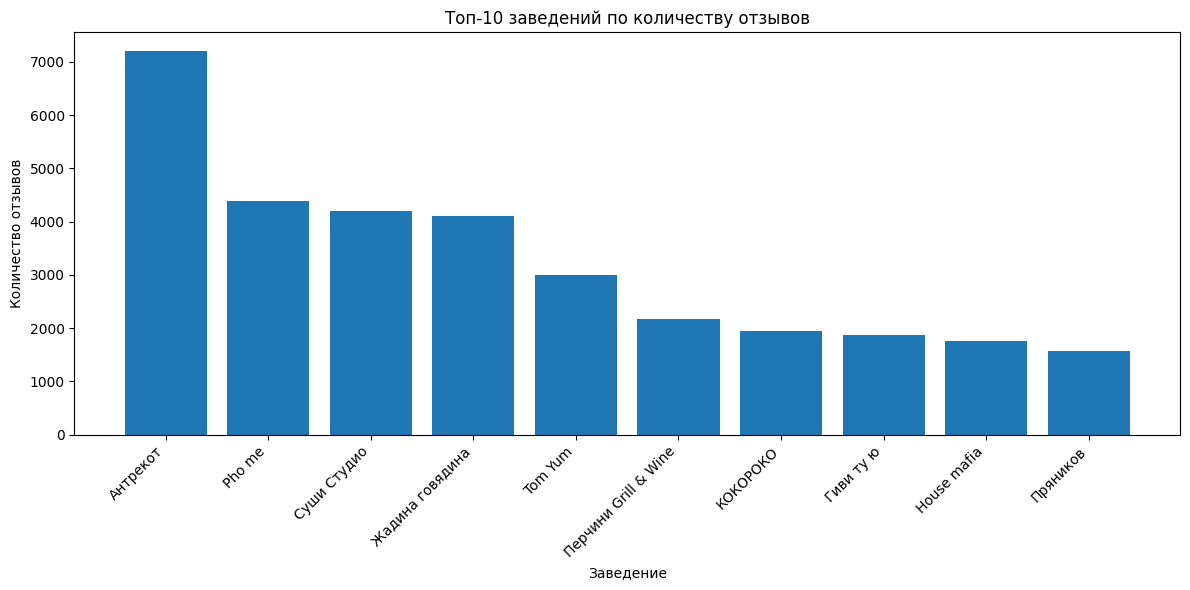


Распределение оценок Жадина-Говядина:
Score
1    1200
2     270
3     191
4     202
5    2250
Name: count, dtype: int64


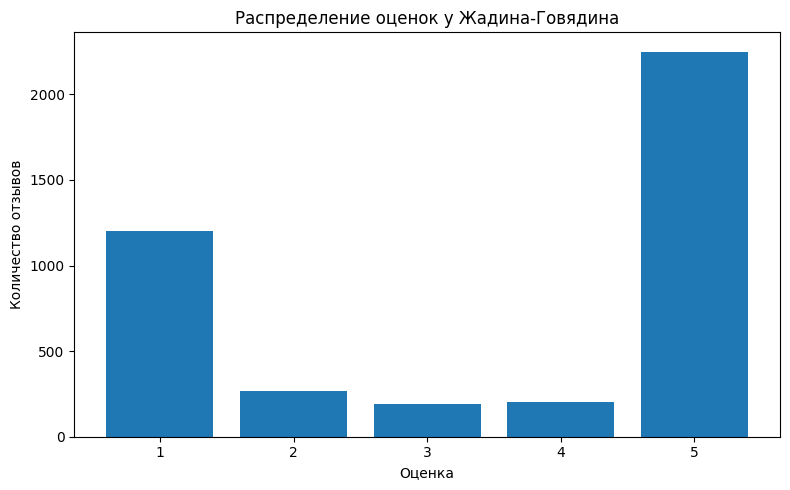


Сравнение средней оценки с конкурентами:
             Бренд  Количество отзывов  Средняя оценка
1         Антрекот                7193            4.65
3          Перчини                2176            4.03
2        ШашлыкoFF                1323            3.61
0  Жадина-Говядина                4113            3.49


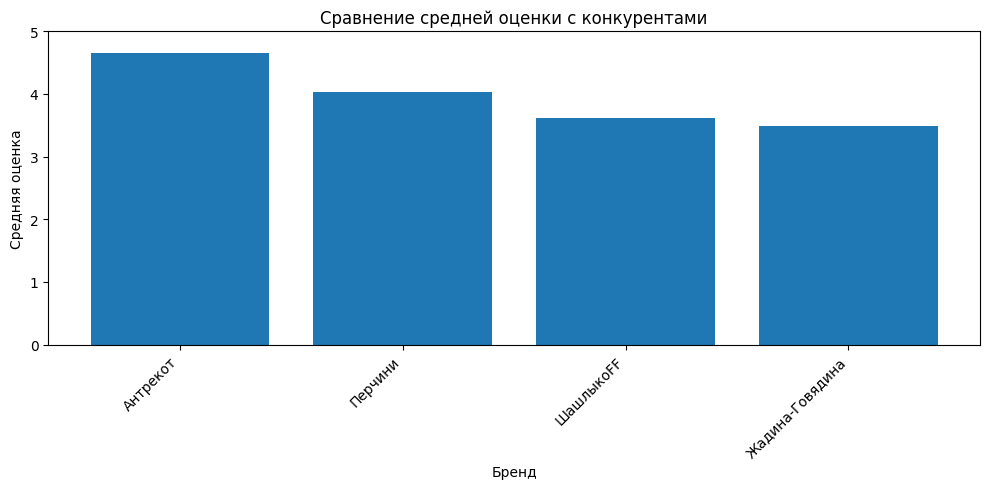


Динамика средней оценки Жадина-Говядина по годам:
Date
2016    3.50
2017    3.24
2018    2.83
2019    3.72
2020    4.07
2021    3.35
2022    3.30
2023    3.52
Name: Score, dtype: float64


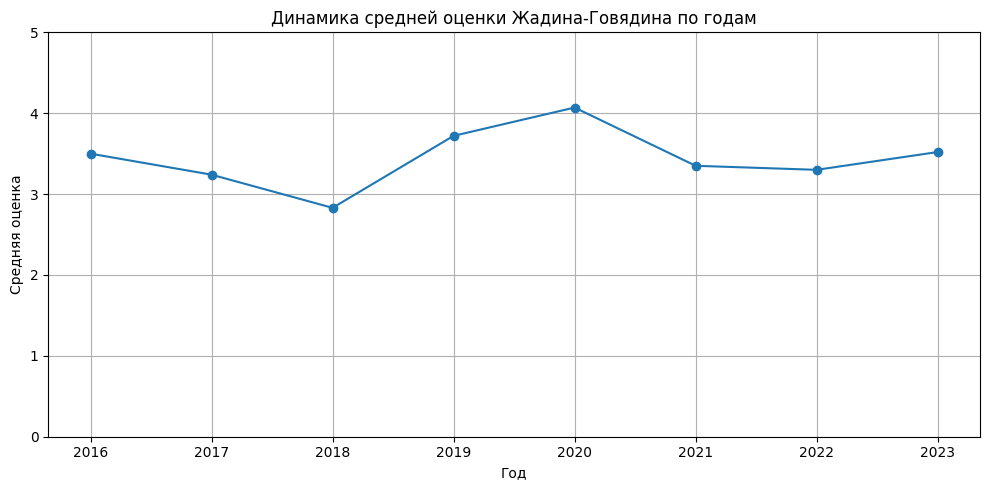


Средний рейтинг по адресам Жадина-Говядина:
Adress
Верхняя Набережная, 145/14, Иркутск    3.84
Седова, 20/1, Иркутск                  3.32
Name: Score, dtype: float64


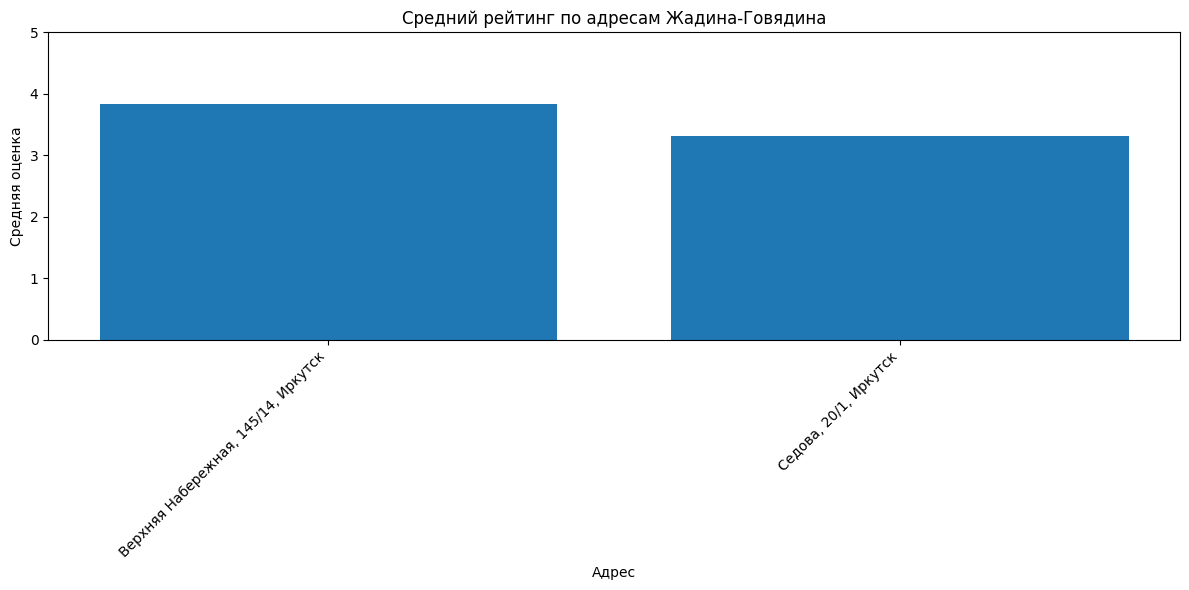

In [18]:
#Топ заведений по количеству отзывов
top_brands = df['Brand'].value_counts().head(10)
print('\nТоп-10 заведений по количеству отзывов:')
print(top_brands)
plt.figure(figsize=(12, 6))
plt.bar(top_brands.index, top_brands.values)
plt.title('Топ-10 заведений по количеству отзывов')
plt.xlabel('Заведение')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Распределение оценок у Жадина-Говядина
target_score_distribution = target['Score'].value_counts().sort_index()
print('\nРаспределение оценок Жадина-Говядина:')
print(target_score_distribution)
plt.figure(figsize=(8, 5))
plt.bar(target_score_distribution.index, target_score_distribution.values)
plt.title('Распределение оценок у Жадина-Говядина')
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

#Сравнение средней оценки с конкурентами
competitors = {
    'Жадина-Говядина': 'жадина',
    'Антрекот': 'антрекот',
    'ШашлыкoFF': 'шашлык',
    'Перчини': 'перчини'
}
comparison_list = []
for brand_name, search_name in competitors.items():

    brand_data = df[df['Brand'].str.contains(search_name, case=False, na=False)]

    reviews_count = len(brand_data)

    if reviews_count > 0:
        mean_score = round(brand_data['Score'].mean(), 2)
    else:
        mean_score = 0

    comparison_list.append([brand_name, reviews_count, mean_score])

comparison_mean_table = pd.DataFrame(
    comparison_list,
    columns=['Бренд', 'Количество отзывов', 'Средняя оценка']
)
comparison_mean_table = comparison_mean_table.sort_values(by='Средняя оценка', ascending=False)
print('\nСравнение средней оценки с конкурентами:')
print(comparison_mean_table)

plt.figure(figsize=(10, 5))
plt.bar(comparison_mean_table['Бренд'], comparison_mean_table['Средняя оценка'])
plt.title('Сравнение средней оценки с конкурентами')
plt.xlabel('Бренд')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Динамика рейтинга Жадина-Говядина по годам
target_reviews_by_year = target.groupby(target['Date'].dt.year)['Score'].mean().round(2)
print('\nДинамика средней оценки Жадина-Говядина по годам:')
print(target_reviews_by_year)
plt.figure(figsize=(10, 5))
plt.plot(target_reviews_by_year.index, target_reviews_by_year.values, marker='o')
plt.title('Динамика средней оценки Жадина-Говядина по годам')
plt.xlabel('Год')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

#Средний рейтинг по адресам Жадина-Говядина
target_rating_by_address = target.groupby('Adress')['Score'].mean().round(2).sort_values(ascending=False)
print('\nСредний рейтинг по адресам Жадина-Говядина:')
print(target_rating_by_address)
plt.figure(figsize=(12, 6))
plt.bar(target_rating_by_address.index, target_rating_by_address.values)
plt.title('Средний рейтинг по адресам Жадина-Говядина')
plt.xlabel('Адрес')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
#Основные причины негативных отзывов Жадина-Говядина связаны с качеством еды и обслуживанием
target_text = df_text[df_text['Brand'].str.contains('жадина', case=False, na=False)].copy()
target_negative = target_text[target_text['Score'] <= 2].copy()

food_words = r'еда|блюд|мяс|стейк|кухн|вкус|невкус|холодн|сыр|пересол|недосол|порци|салат|суп|бургер|картош|шашлык|куриц|говядин|гарнир|соус|десерт'
service_words = r'официант|персонал|обслуж|сервис|хам|груб|невеж|администратор|менеджер|не подош|забыли|игнор|отношение|кассир'
speed_words = r'долго|ждал|ждали|ждать|ожидан|медлен|очеред|несли|принесли|подач|задерж|час|минут'
price_words = r'дорог|цена|ценник|стоимость|чек|переплат|деньг|скидк'
atmosphere_words = r'гряз|шум|музык|интерьер|атмосфер|зал|стол|туалет|посадк|мест'

target_negative['Жалоба_еда'] = target_negative['Comment_clean'].str.contains(food_words, case=False, regex=True)
target_negative['Жалоба_обслуживание'] = target_negative['Comment_clean'].str.contains(service_words, case=False, regex=True)
target_negative['Жалоба_скорость'] = target_negative['Comment_clean'].str.contains(speed_words, case=False, regex=True)
target_negative['Жалоба_цена'] = target_negative['Comment_clean'].str.contains(price_words, case=False, regex=True)
target_negative['Жалоба_атмосфера'] = target_negative['Comment_clean'].str.contains(atmosphere_words, case=False, regex=True)

food_count = target_negative['Жалоба_еда'].sum()
service_count = target_negative['Жалоба_обслуживание'].sum()
speed_count = target_negative['Жалоба_скорость'].sum()
price_count = target_negative['Жалоба_цена'].sum()
atmosphere_count = target_negative['Жалоба_атмосфера'].sum()

food_percent = round(food_count / len(target_negative) * 100, 2)
service_percent = round(service_count / len(target_negative) * 100, 2)
speed_percent = round(speed_count / len(target_negative) * 100, 2)
price_percent = round(price_count / len(target_negative) * 100, 2)
atmosphere_percent = round(atmosphere_count / len(target_negative) * 100, 2)

complaints_table = pd.DataFrame({
    'Категория жалобы': [
        'Качество еды',
        'Обслуживание',
        'Скорость обслуживания',
        'Цена',
        'Атмосфера'
    ],
    'Количество отзывов': [
        food_count,
        service_count,
        speed_count,
        price_count,
        atmosphere_count
    ],
    'Доля от негативных отзывов, %': [
        food_percent,
        service_percent,
        speed_percent,
        price_percent,
        atmosphere_percent
    ]
})

complaints_table = complaints_table.sort_values(by='Количество отзывов', ascending=False)

print(complaints_table)

        Категория жалобы  Количество отзывов  Доля от негативных отзывов, %
1           Обслуживание                1166                          79.32
2  Скорость обслуживания                1054                          71.70
0           Качество еды                 880                          59.86
4              Атмосфера                 848                          57.69
3                   Цена                 127                           8.64
